In [1]:
from sklearn.tree import DecisionTreeClassifier
import numpy as np

# Sample data (Hours studied)
X = np.array([[1], [2], [3], [4], [5]])
y = np.array([0, 0, 0, 1, 1])  # 0 = Fail, 1 = Pass

# Create model
model = DecisionTreeClassifier()

# Train model
model.fit(X, y)

# Predict
prediction = model.predict([[3.5]])
print("Prediction (0=Fail, 1=Pass):", prediction)



Prediction (0=Fail, 1=Pass): [0]


In [12]:
from sklearn.tree import DecisionTreeRegressor
import numpy as np

# Sample data
X = np.array([[1], [2], [3], [4], [5]])
y = np.array([10000, 20000, 30000, 40000, 50000])  # Salary

# Create model
model = DecisionTreeRegressor()

# Train model
model.fit(X, y)

# Predict
prediction = model.predict([[3.5]])
print("Predicted Salary:", prediction)



Predicted Salary: [30000.]


In [5]:
!pip install mlxtend

   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ------- -------------------------------- 0.3/1.4 MB ? eta -:--:--
   ----------------------- ---------------- 0.8/1.4 MB 3.2 MB/s eta 0:00:01
   ---------------------------------------- 1.4/1.4 MB 3.0 MB/s  0:00:00
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ------ --------------------------------- 1.3/8.1 MB 7.6 MB/s eta 0:00:01
   ------------ --------------------------- 2.6/8.1 MB 7.0 MB/s eta 0:00:01
   ------------------- -------------------- 3.9/8.1 MB 7.1 MB/s eta 0:00:01
   ----------------------------- ---------- 6.0/8.1 MB 7.3 MB/s eta 0:00:01
   ------------------------------------- -- 7.6/8.1 MB 7.5 MB/s eta 0:00:01
   ---------------------------------------- 8.1/8.1 MB 7.1 MB/s  0:00:01
   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.0 MB 6.9 MB/s eta 0:00:02
   ----- ---------------------------------- 1.

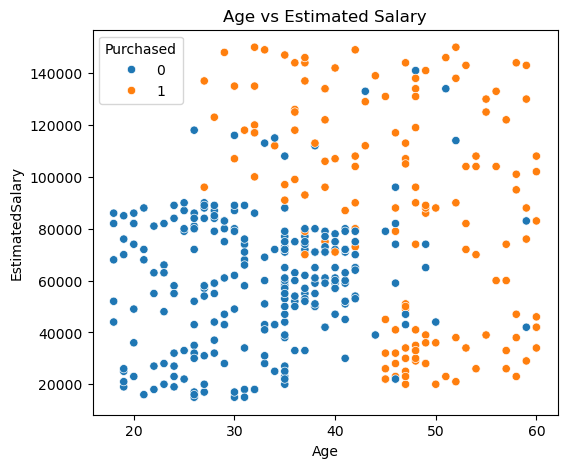

Accuracy (Gini): 0.9
Accuracy (Entropy): 0.91


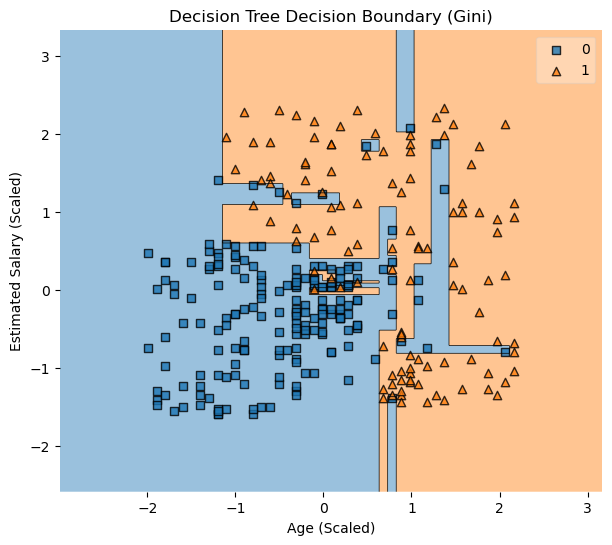

In [6]:
# ===============================
# Step 1: Import Libraries
# ===============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from mlxtend.plotting import plot_decision_regions

# ===============================
# Step 2: Load Dataset
# ===============================
dataset = pd.read_csv("Social_Network_Ads.csv")

# ===============================
# Step 3: Scatter Plot (Non-Linear Pattern)
# ===============================
plt.figure(figsize=(6,5))
sns.scatterplot(
    x="Age",
    y="EstimatedSalary",
    hue="Purchased",
    data=dataset
)
plt.title("Age vs Estimated Salary")
plt.show()

# ===============================
# Step 4: Select Features & Target
# ===============================
X = dataset[["Age", "EstimatedSalary"]].values
y = dataset["Purchased"].values

# ===============================
# Step 5: Train Test Split
# ===============================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=0
)

# ===============================
# Step 6: Feature Scaling
# ===============================
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

# ===============================
# Step 7A: Train Decision Tree (Gini)
# ===============================
model_gini = DecisionTreeClassifier(
    criterion="gini",
    random_state=0
)
model_gini.fit(X_train, y_train)

# Accuracy
y_pred_gini = model_gini.predict(X_test)
print("Accuracy (Gini):", accuracy_score(y_test, y_pred_gini))

# ===============================
# Step 7B: Train Decision Tree (Entropy)
# ===============================
model_entropy = DecisionTreeClassifier(
    criterion="entropy",
    random_state=0
)
model_entropy.fit(X_train, y_train)

# Accuracy
y_pred_entropy = model_entropy.predict(X_test)
print("Accuracy (Entropy):", accuracy_score(y_test, y_pred_entropy))

# ===============================
# Step 8: Plot Decision Boundary (Gini)
# ===============================
plt.figure(figsize=(7,6))
plot_decision_regions(X_train, y_train, clf=model_gini)
plt.title("Decision Tree Decision Boundary (Gini)")
plt.xlabel("Age (Scaled)")
plt.ylabel("Estimated Salary (Scaled)")
plt.show()